In [74]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import make_models_script
import glob

import matplotlib.pyplot as plt
from matplotlib import rcParams


params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [75]:
mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


In [76]:
summary_df = pd.read_csv("data_lines_with_vals.csv")

def compute_mn_fe_model(row, fe_centers):
    return (row['slope_mn_fe'] * fe_centers) + row['intercept_mn_fe']

summary_df['mn_fe_model_vals'] = summary_df.apply(
    lambda r: compute_mn_fe_model(r, fe_mg_centers).tolist(), axis=1
)

In [77]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def plot_mn_fe(param_to_plot, models_files_dir):
    
    # 1. Load the model files and extract the iteration number
    dfs = []
    plot_file_pattern = f"{models_files_dir}/{param_to_plot}_*"
    to_plot_files = glob.glob(plot_file_pattern)

    for path in to_plot_files:
        df = pd.read_csv(path)
        
        # Extract iteration number from the filename (e.g., 'param_iter3_0.csv')
        match = re.search(r'iter(\d+)', path)
        if match:
            df['iteration'] = int(match.group(1))
        else:
            df['iteration'] = 0
            
        dfs.append(df)

    if not dfs:
        print("No data found.")
        return

    all_dfs = pd.concat(dfs, ignore_index=True)
    
    # Set colorbar limits based on iterations instead of parameter values
    vmin = all_dfs['iteration'].min()
    vmax = all_dfs['iteration'].max()

    # 2. Check which bins actually have data so we don't show empty plots
    valid_bins = []
    for center in mg_h_big_bin_centers:
        bin_has_data = False
        for df in dfs:
            mask = np.isclose(df['mg_h_bin'], center)
            if sum(mask) > 0:
                bin_has_data = True
                break 
        
        if bin_has_data:
            valid_bins.append(center)
            
    if not valid_bins:
        print("No data in the specified bins.")
        return

    # 3. Plotting loop
    # Dynamically size the figure based on the number of non-empty plots
    plt.figure(figsize=(4 * len(valid_bins), 5))
    sc = None 

    for idx, center in enumerate(valid_bins):
        plt.subplot(1, len(valid_bins), idx + 1)
        
        for df in dfs:
            mask = np.isclose(df['mg_h_bin'], center)
            subset = df[mask]
            
            if len(subset) == 0:
                continue
            
            # Standard scatter colored by iteration
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                             c=subset['iteration'], 
                             cmap='viridis', vmin=vmin, vmax=vmax)
                
        # Plot summary data
        mask_data = np.isclose(summary_df['mg_h_bin_center'], center)
        data_subset = summary_df[mask_data]

        if len(data_subset) > 0:
            plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

        if idx == 0:
            plt.ylabel('[Mn/Fe]')
            # plt.legend(bbox_to_anchor=[-0.5, 1]) # Legend commented out

        plt.grid(True, alpha=0.3)
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.xlabel('[Fe/Mg]')
        plt.title(f"[Mg/H] ~ {center:.2f}")

        if sc is not None:
            cbar = plt.colorbar(sc, ax=plt.gca()) 
            cbar.set_label('Iteration')
        
    plt.tight_layout()
    plt.show()

# Models 1

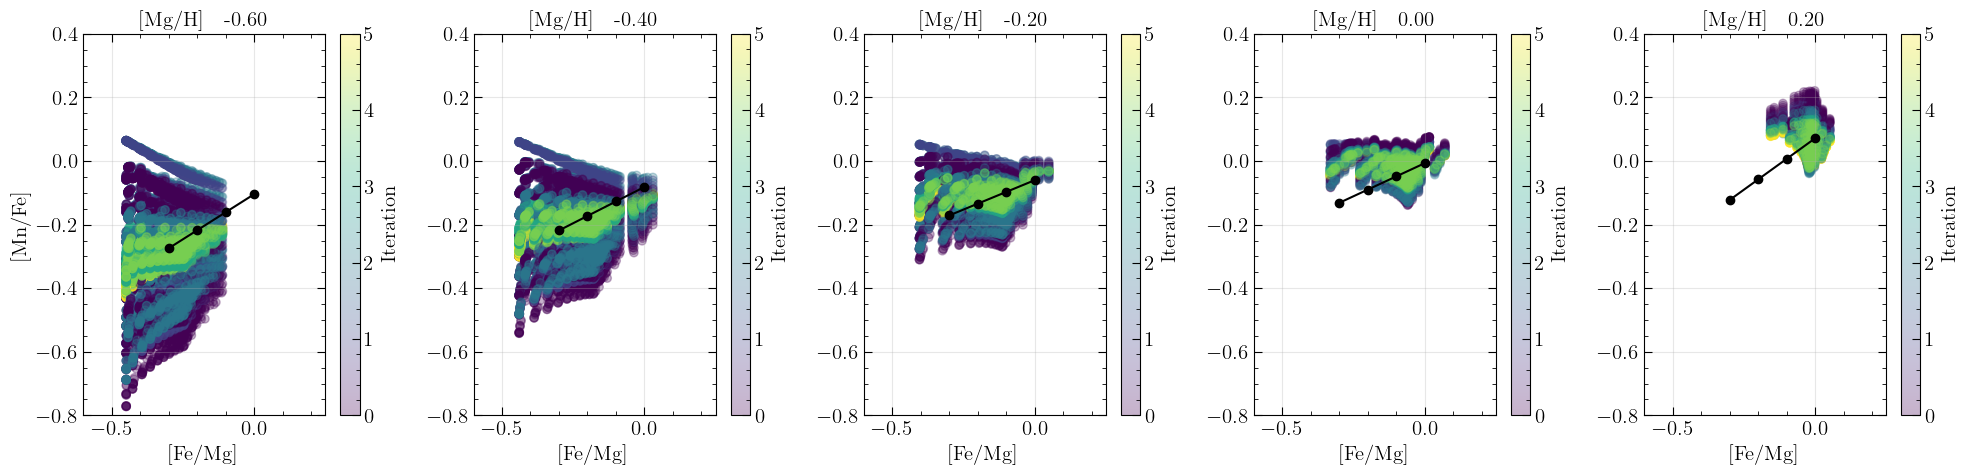

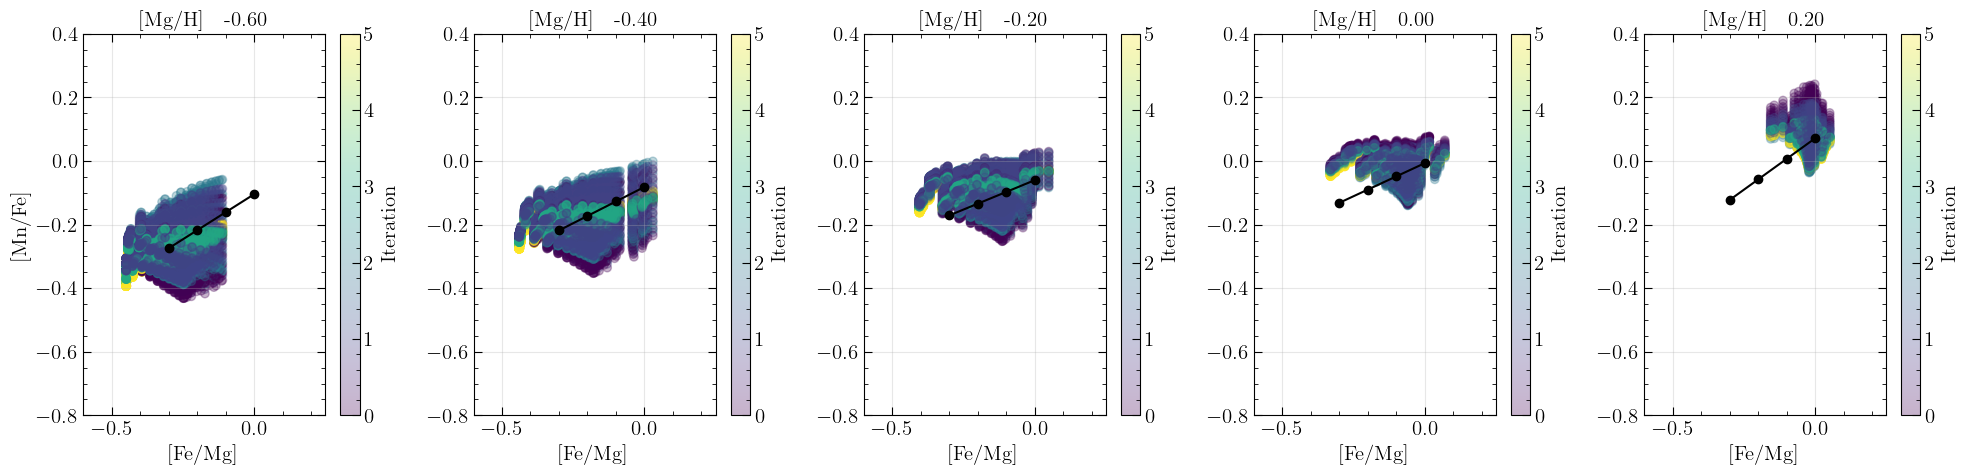

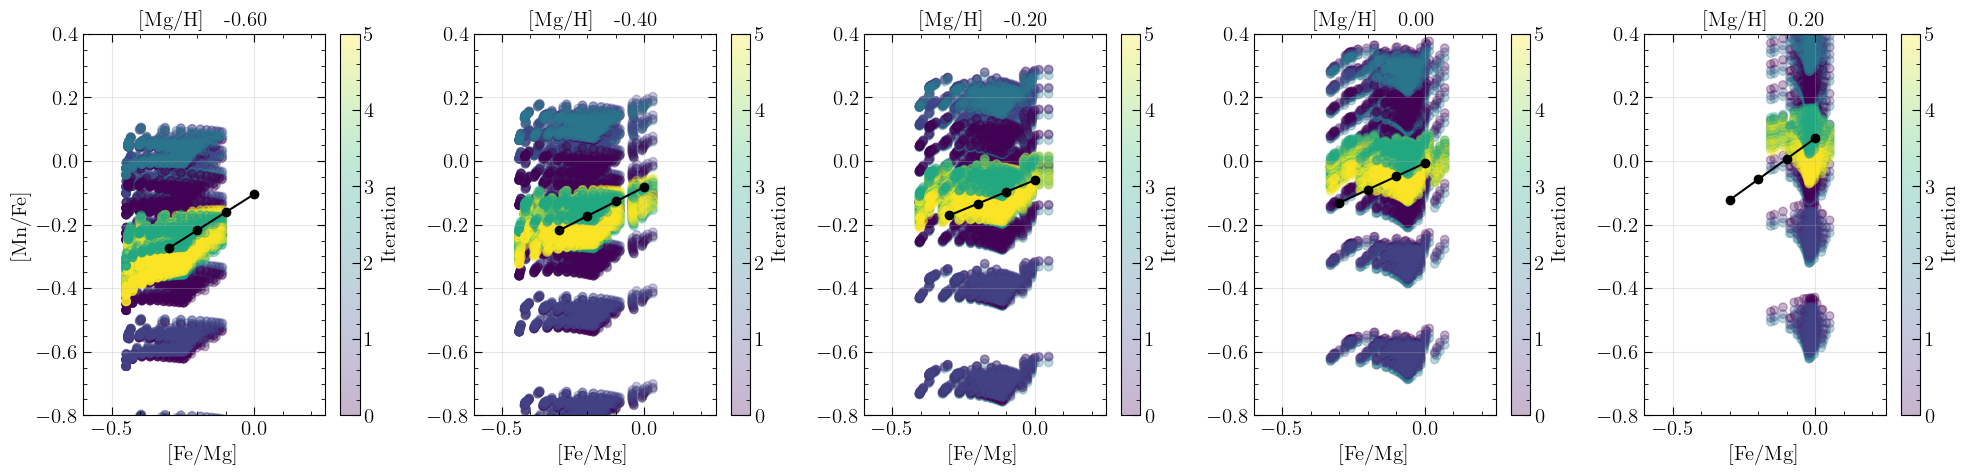

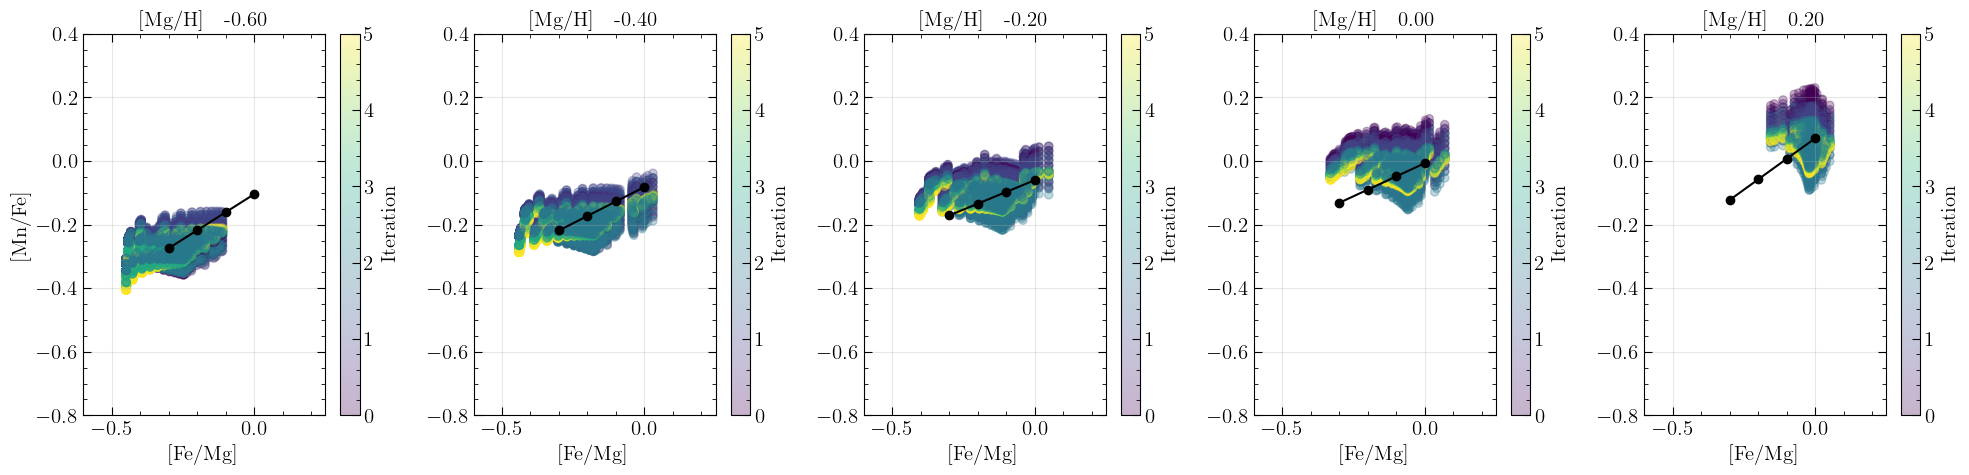

In [78]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_1")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_1")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_1")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_1")

# Models 3

 --alpha_cc 0.50 --alpha_Ia 0.80 --g_cc 0.40 --g_ratio 1.90 --save_dir "unity_models_3"

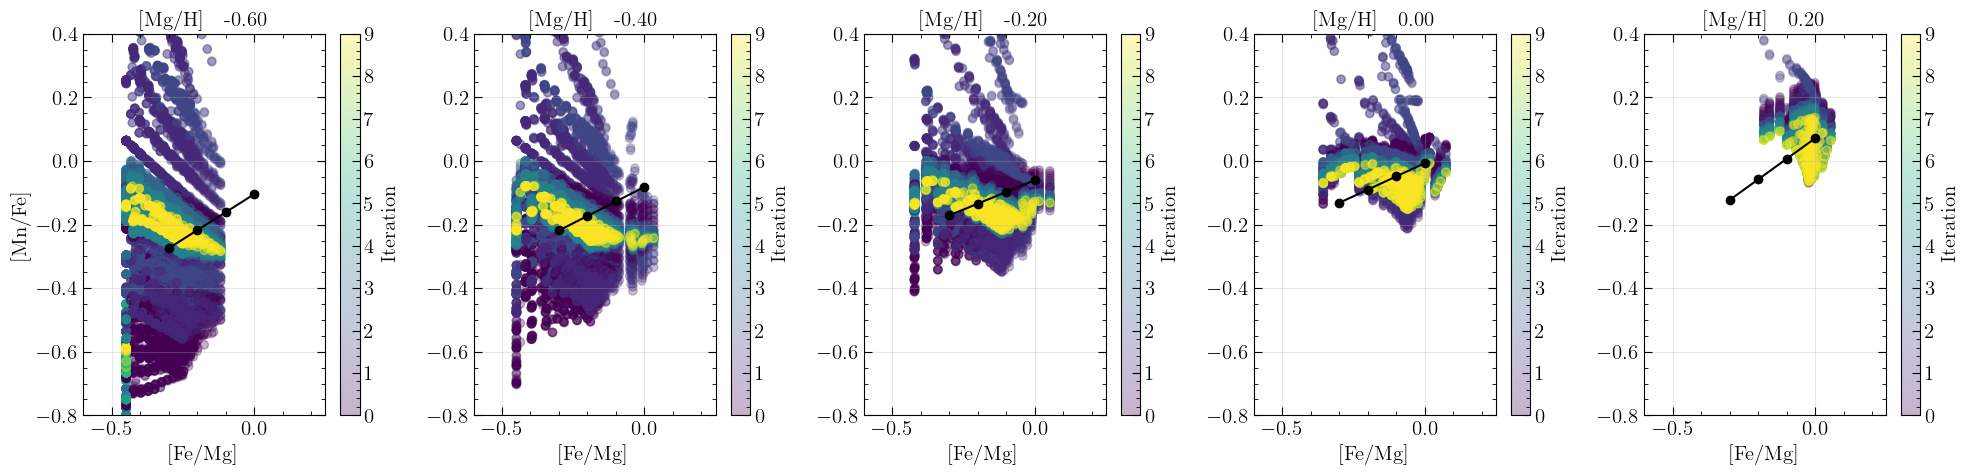

In [79]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_3")

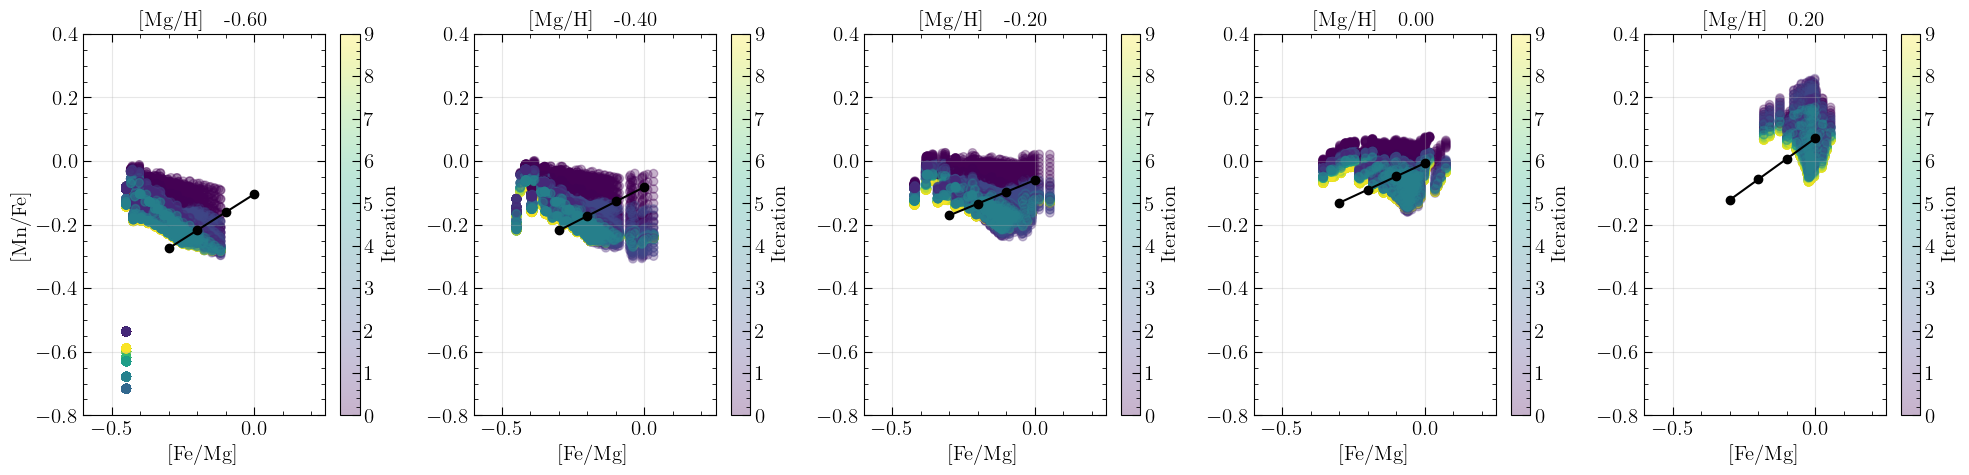

In [80]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_3")

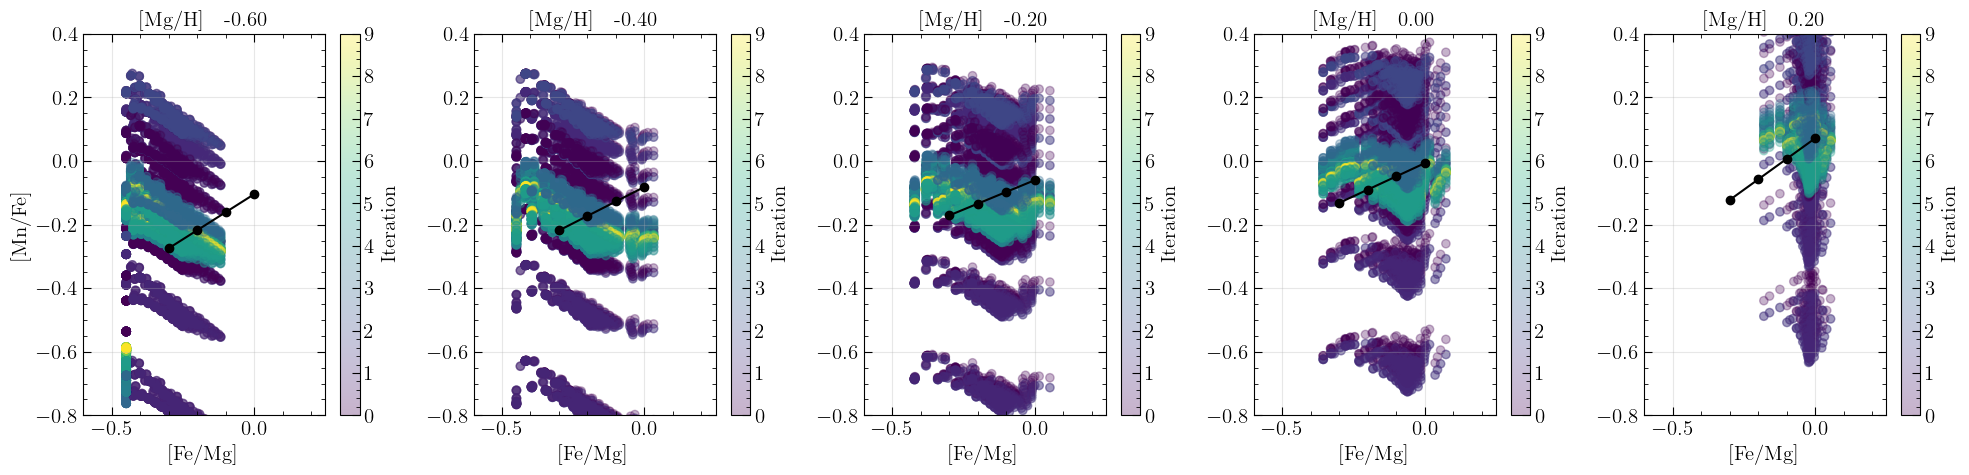

In [81]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_3")

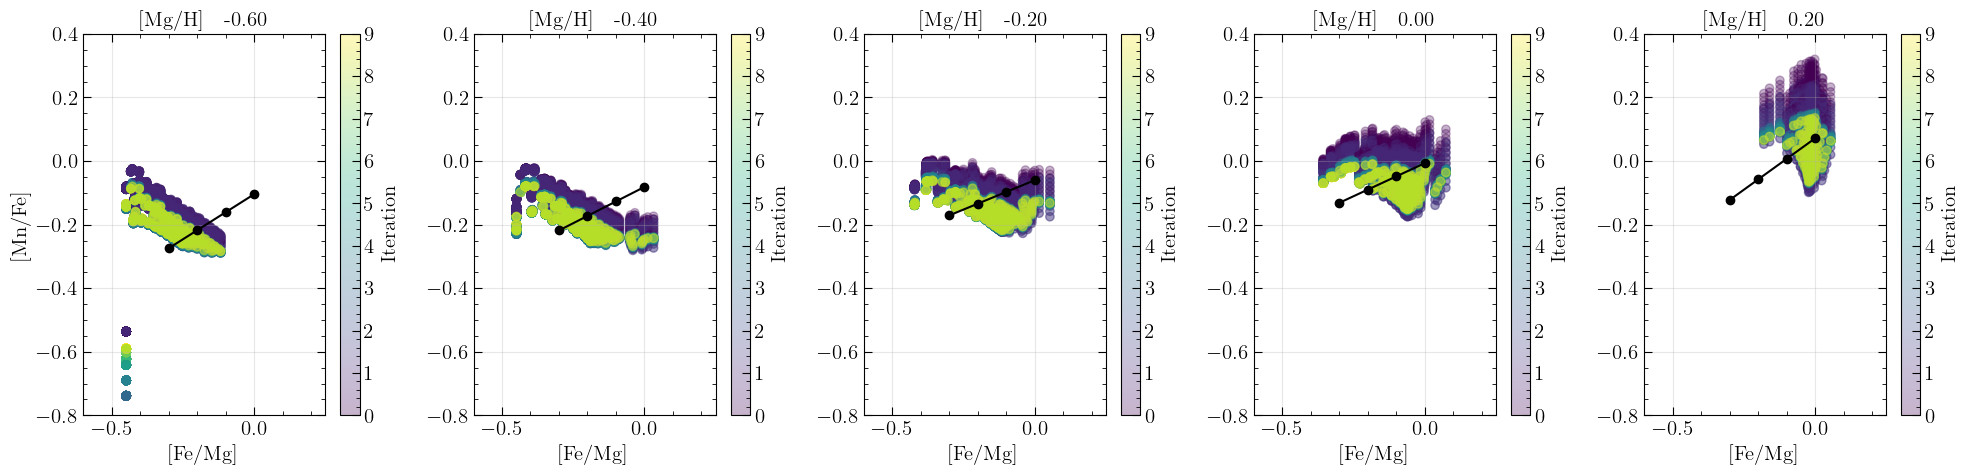

In [82]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_3")

# Models 4

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.20 --g_ratio 1.90 --save_dir "unity_models_4"

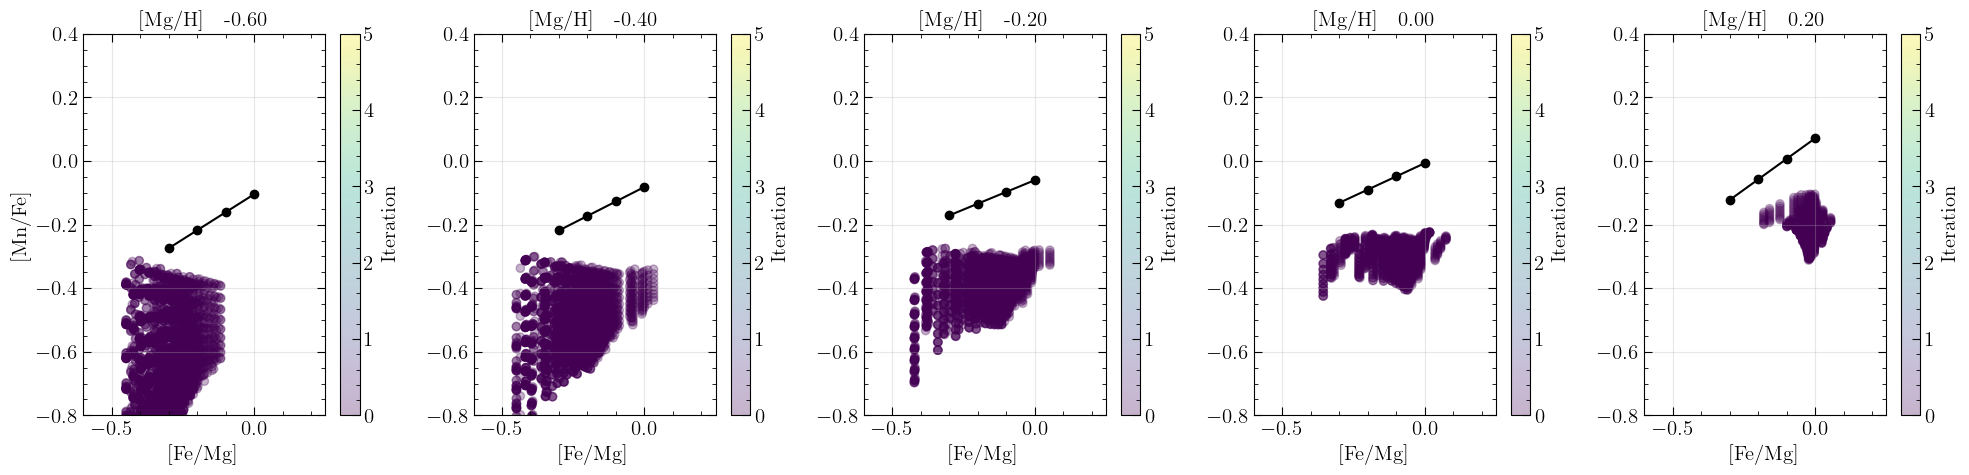

In [83]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_4")

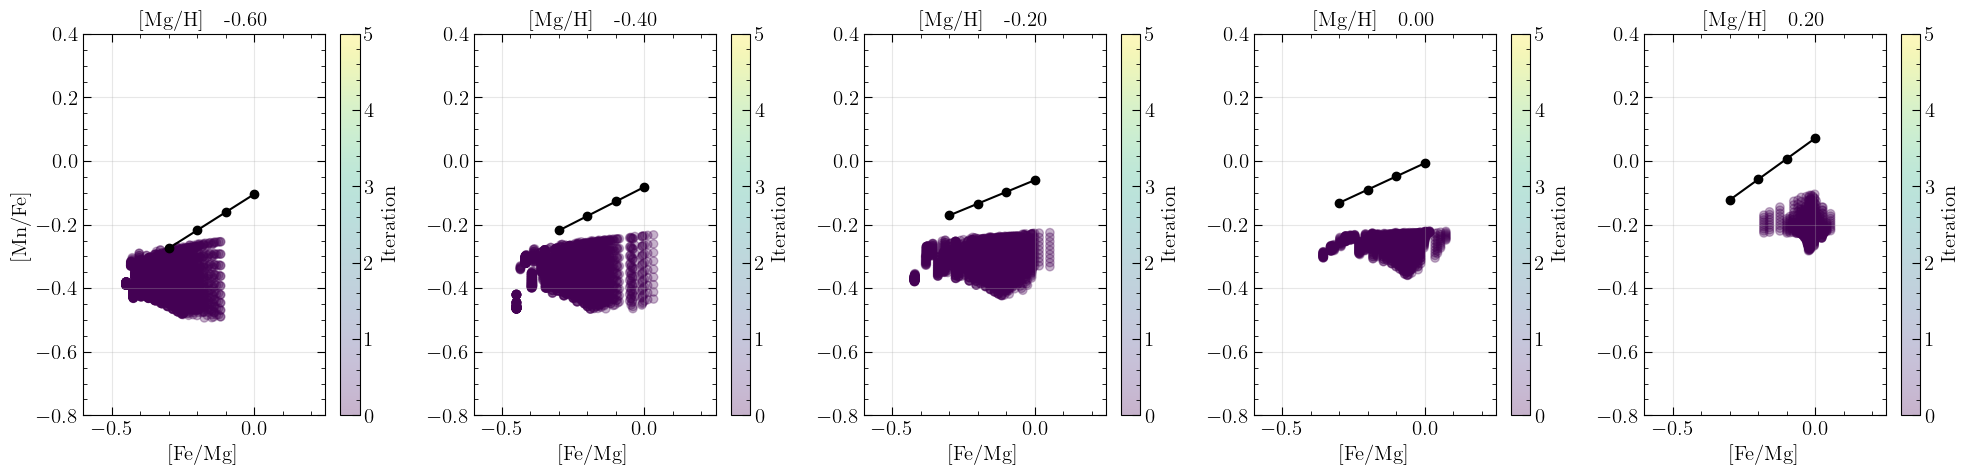

In [84]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_4")

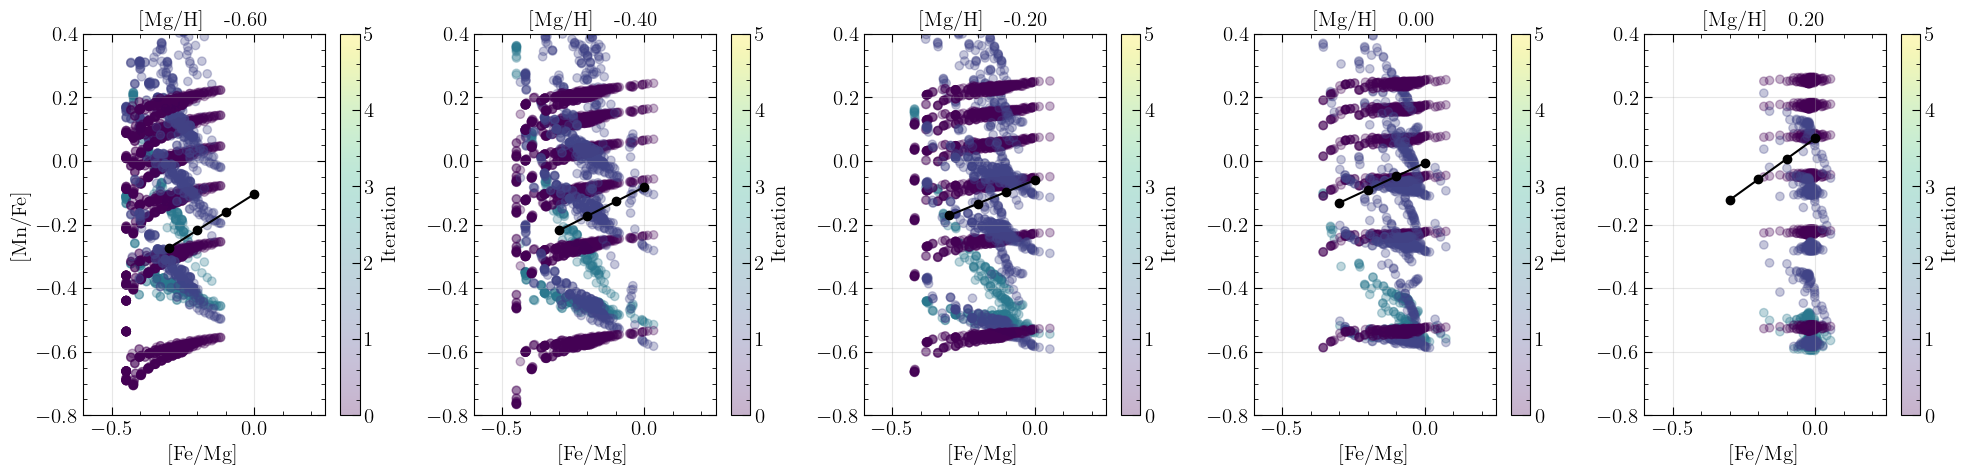

In [85]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_4")

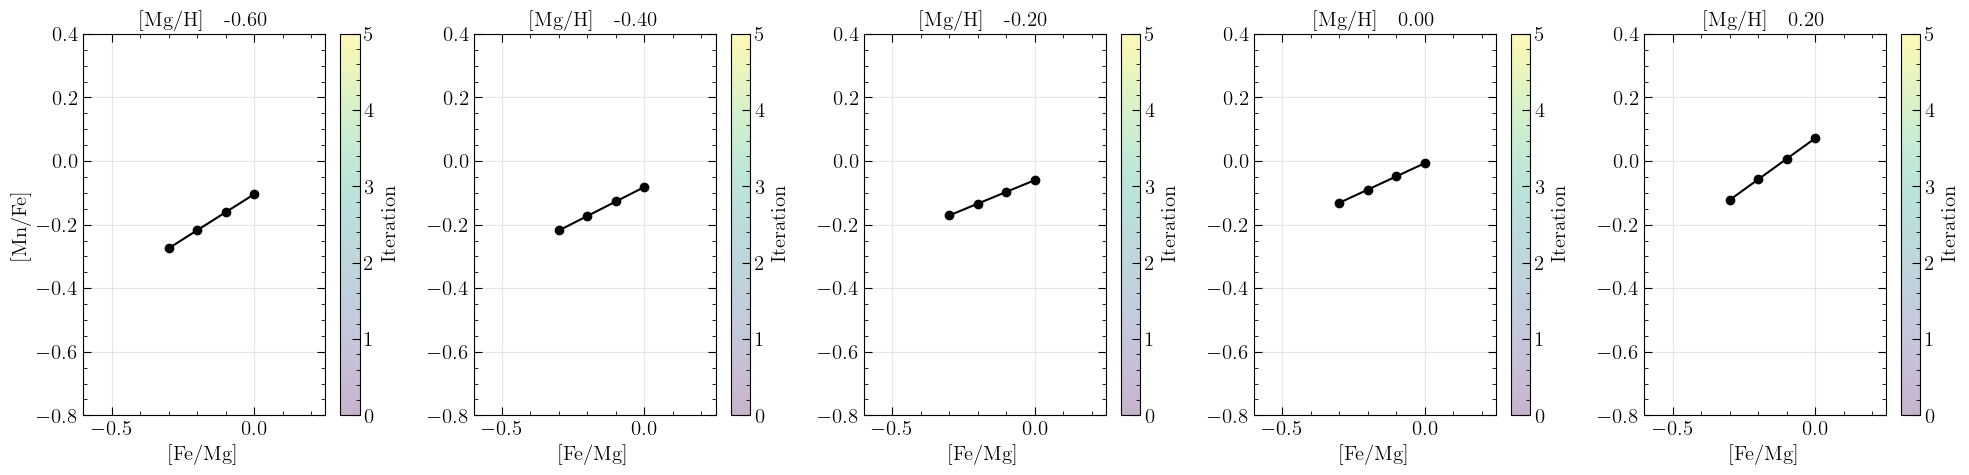

In [86]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_4")

# Models 5

 --alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.80 --g_ratio 1.90 --save_dir "unity_models_5"

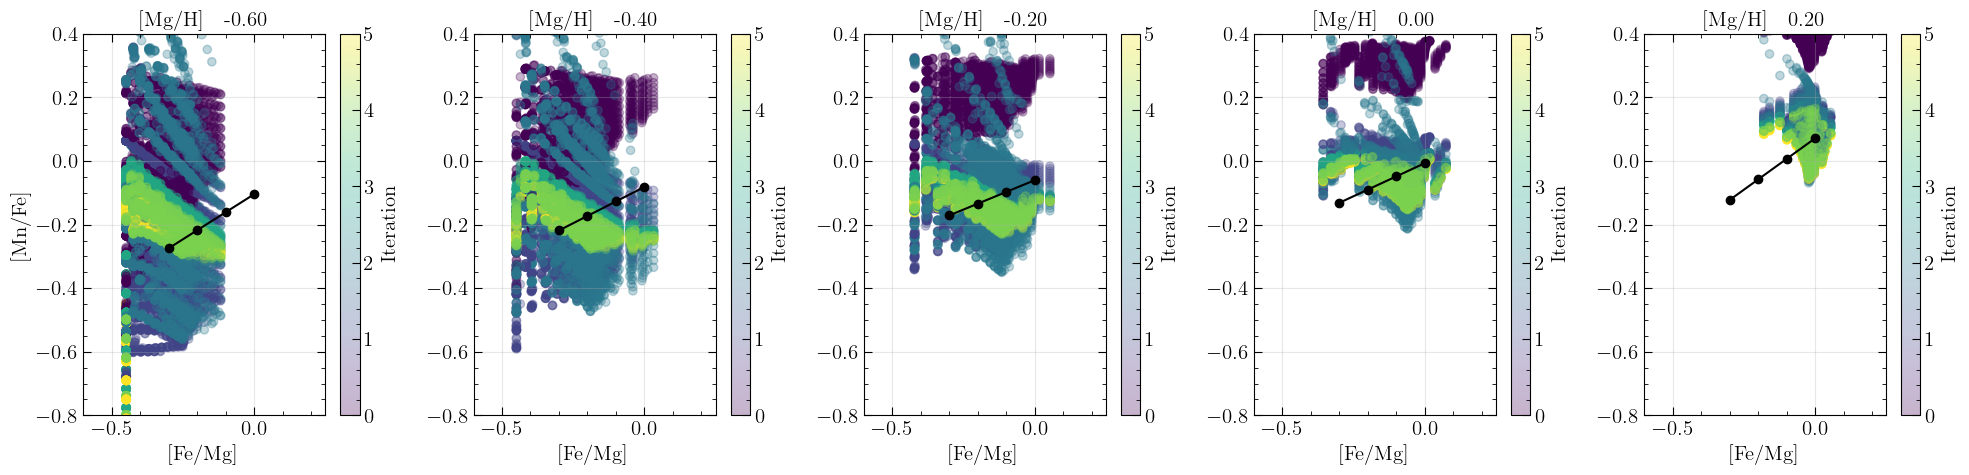

In [87]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_5")

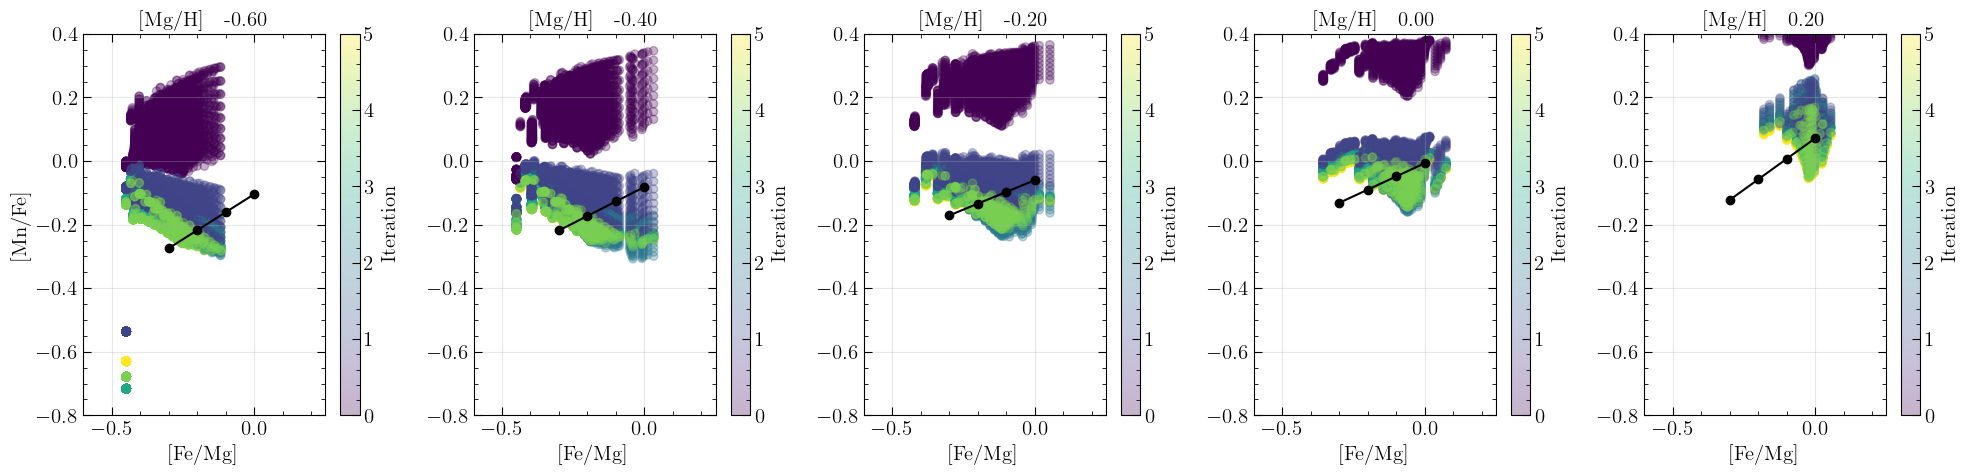

In [88]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_5")

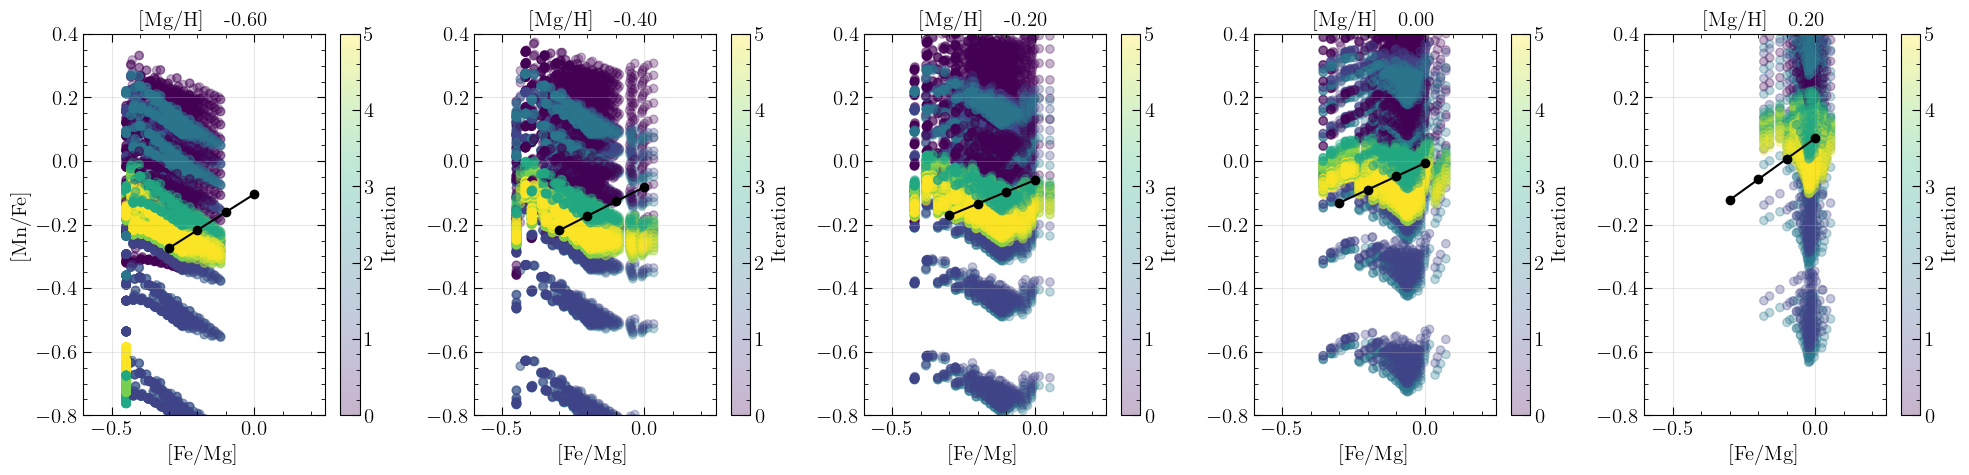

In [89]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_5")

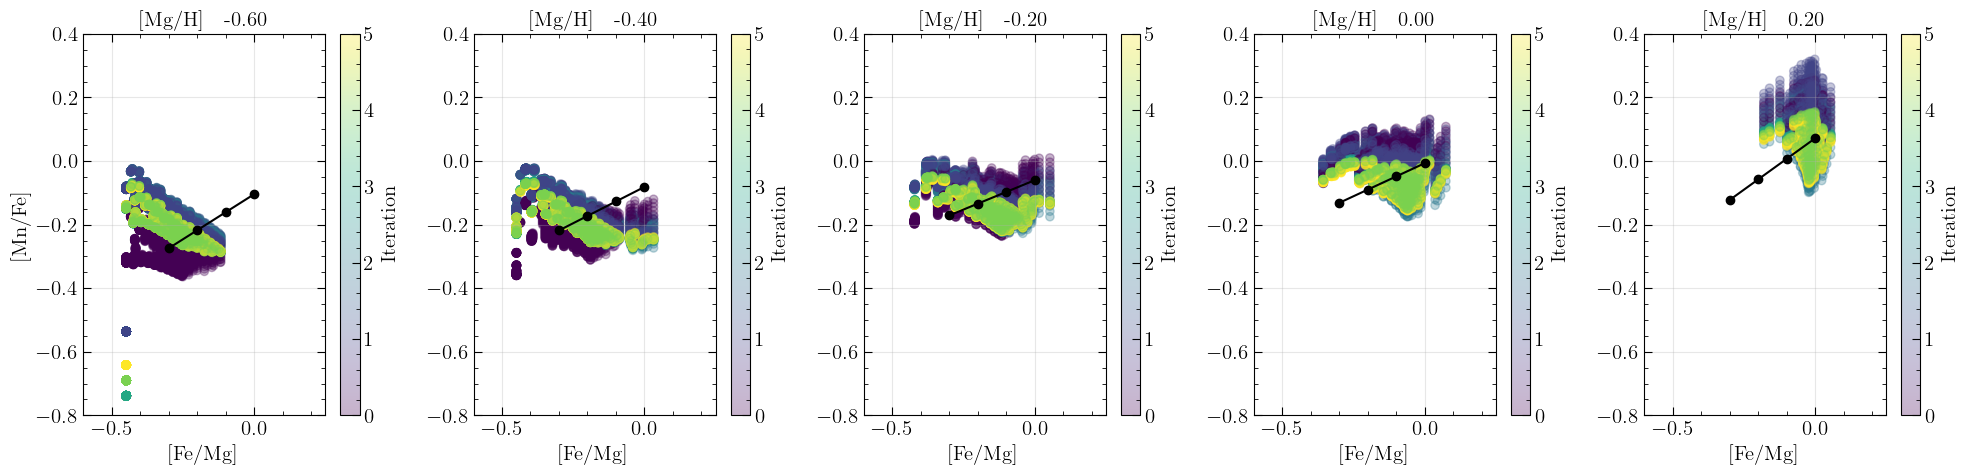

In [90]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_5")

# Models 6

--alpha_cc 0.30 --alpha_Ia 0.20 --g_cc 0.30 --g_ratio 1.80 --save_dir "unity_models_6" 

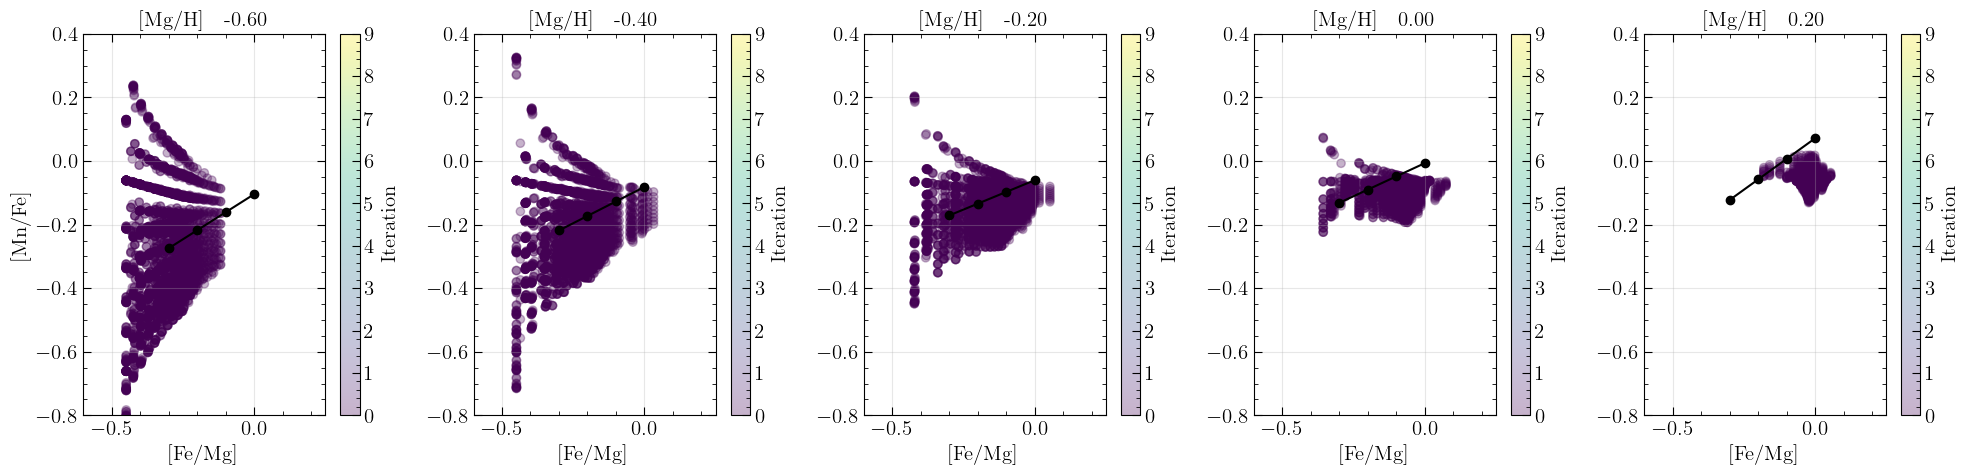

In [91]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_6")

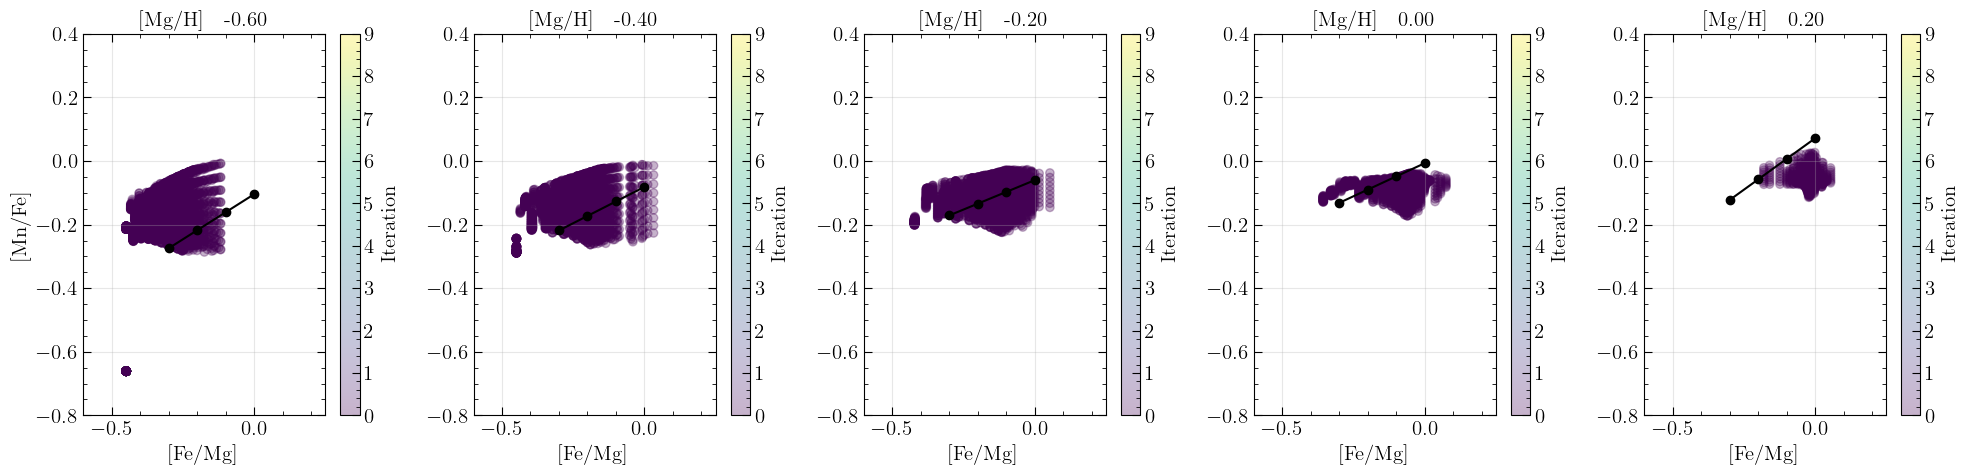

In [92]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_6")

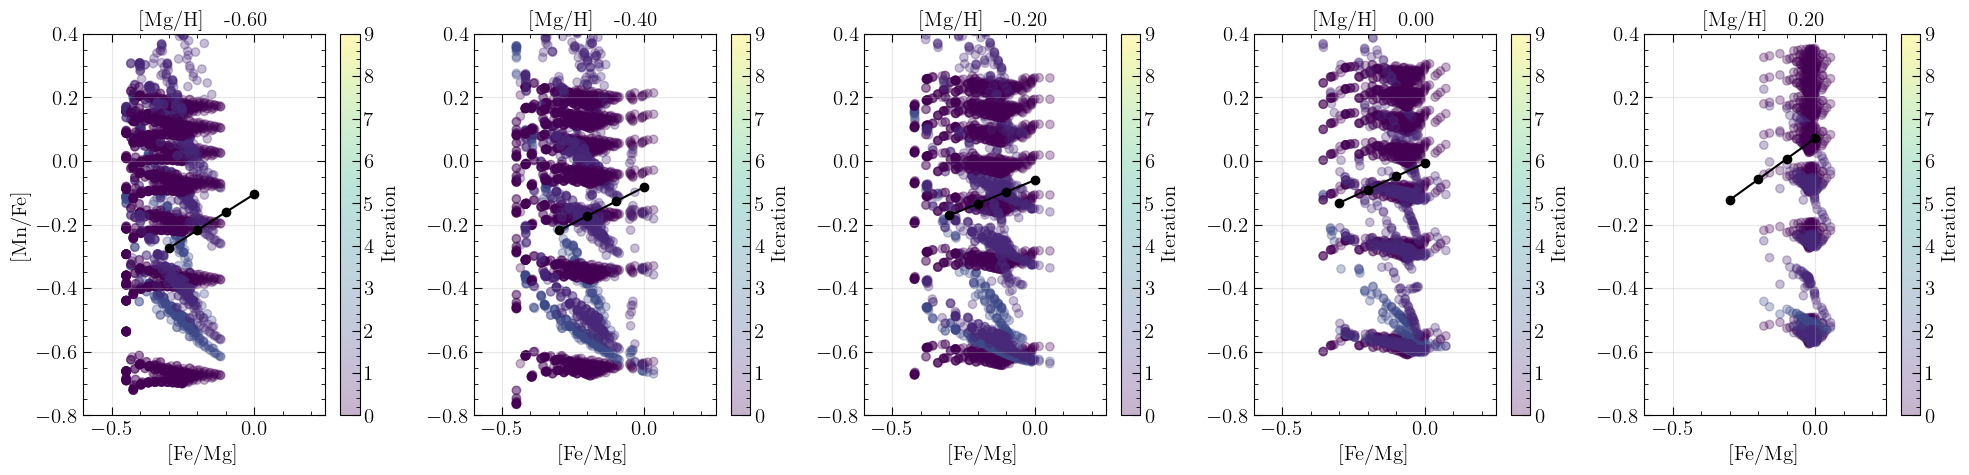

In [93]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_6")

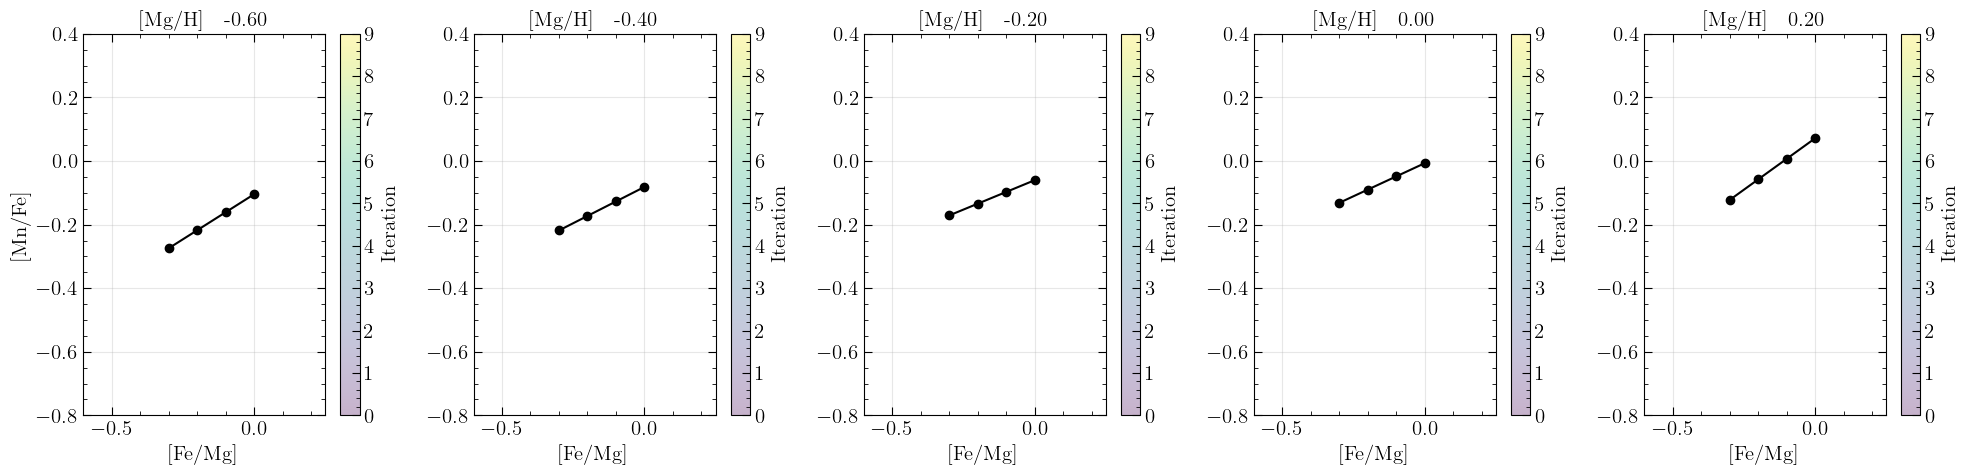

In [94]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_6")

# Models 7

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.40 --g_ratio 2.2 --save_dir "unity_models_7"

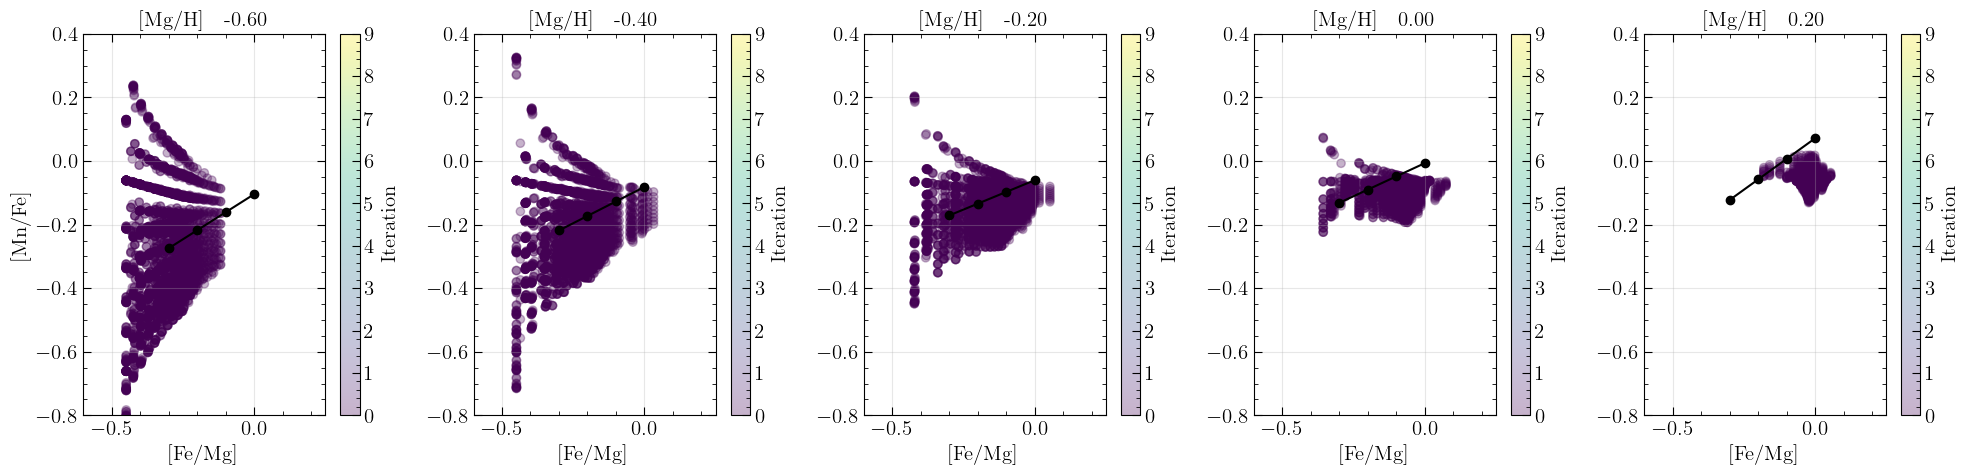

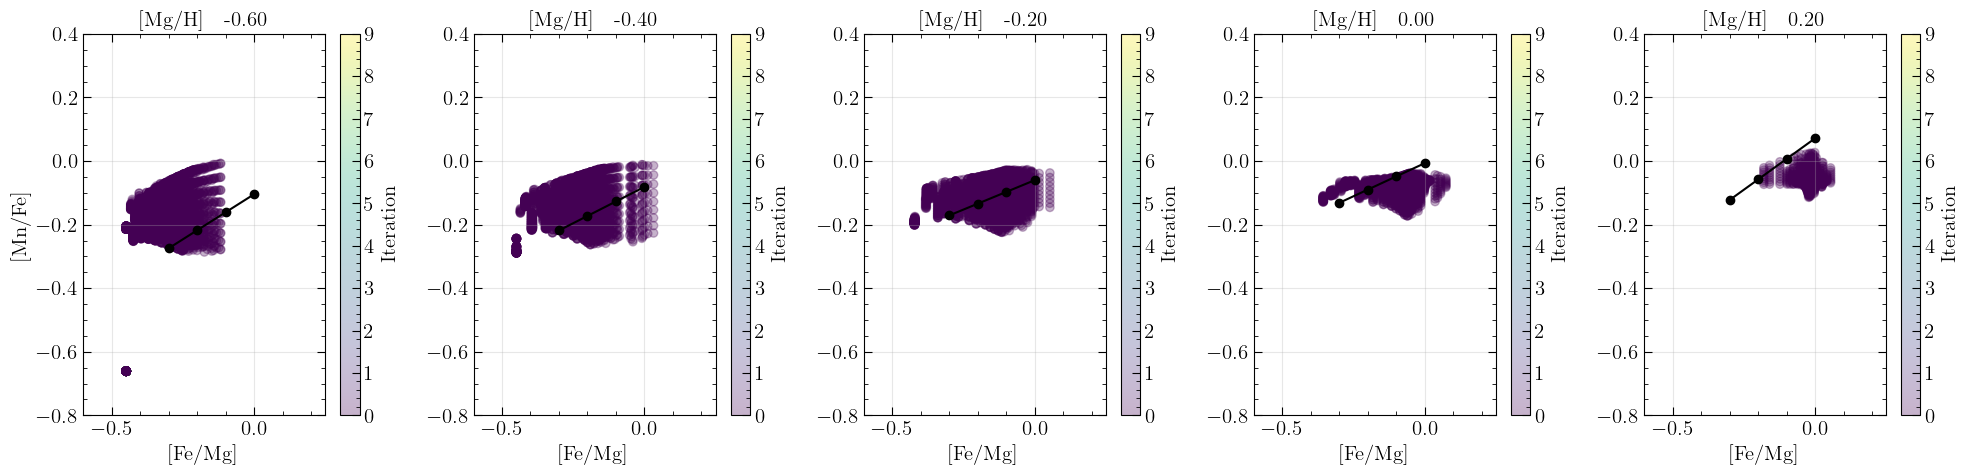

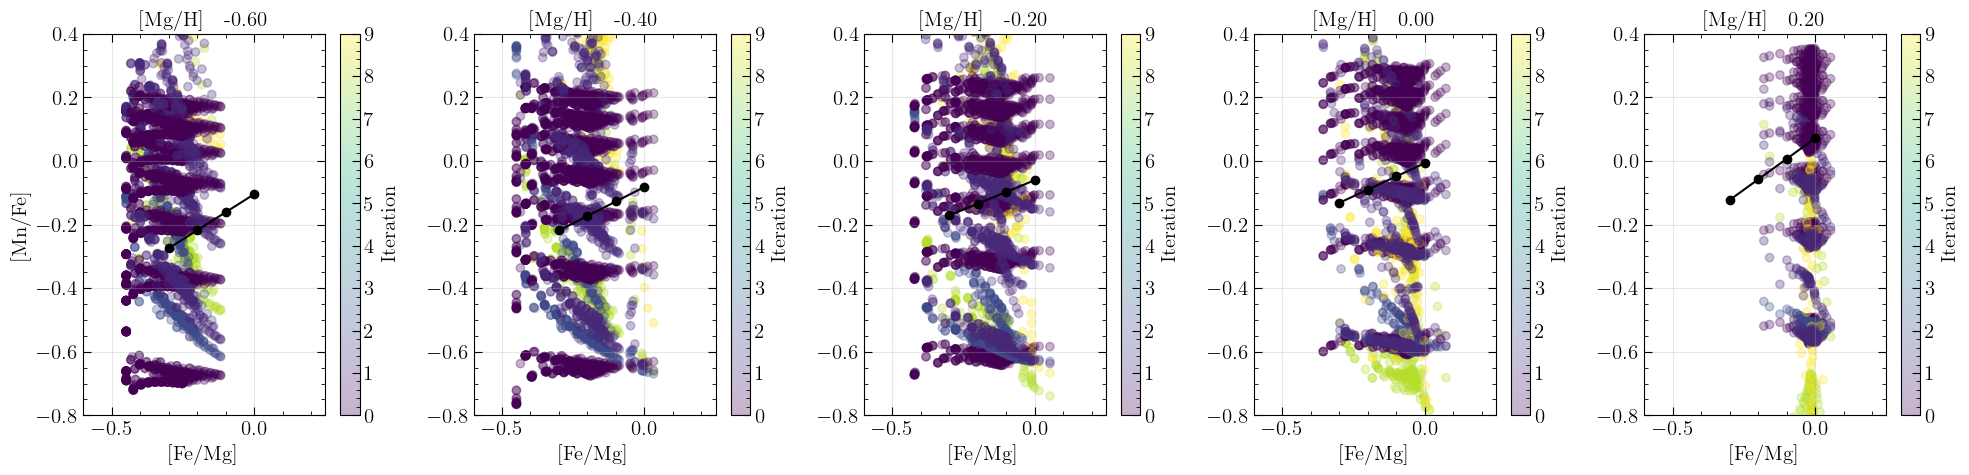

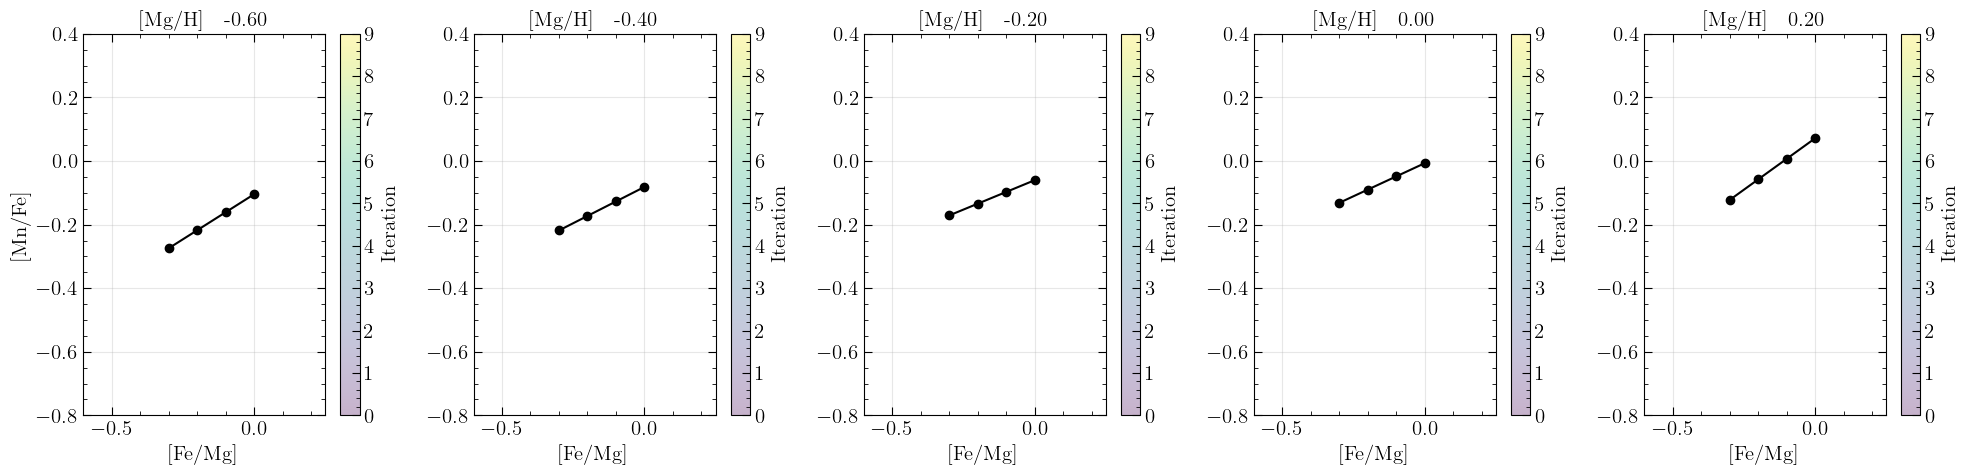

In [95]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_7_same_grid_len")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_7_same_grid_len")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_7_same_grid_len")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_7_same_grid_len")

# Models 8

--alpha_cc 0.20 --alpha_Ia 0.80 --g_cc 0.20 --g_ratio 1.60 --save_dir "unity_models_8"

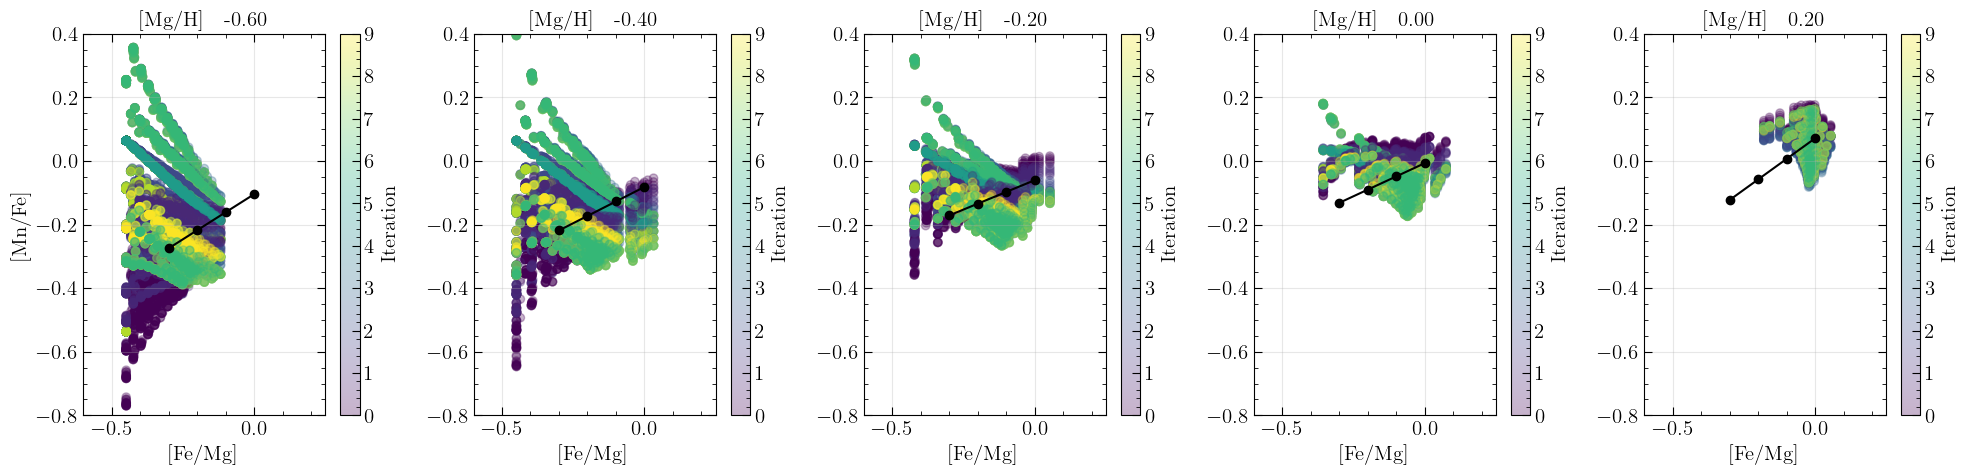

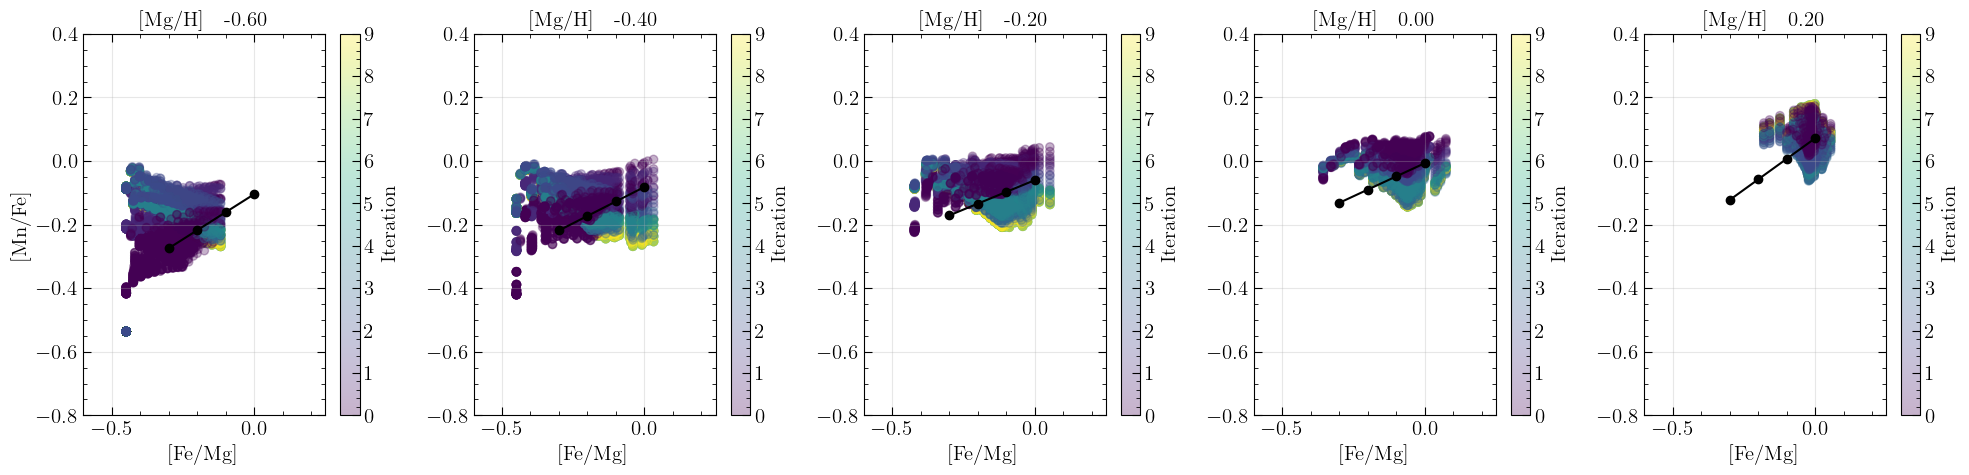

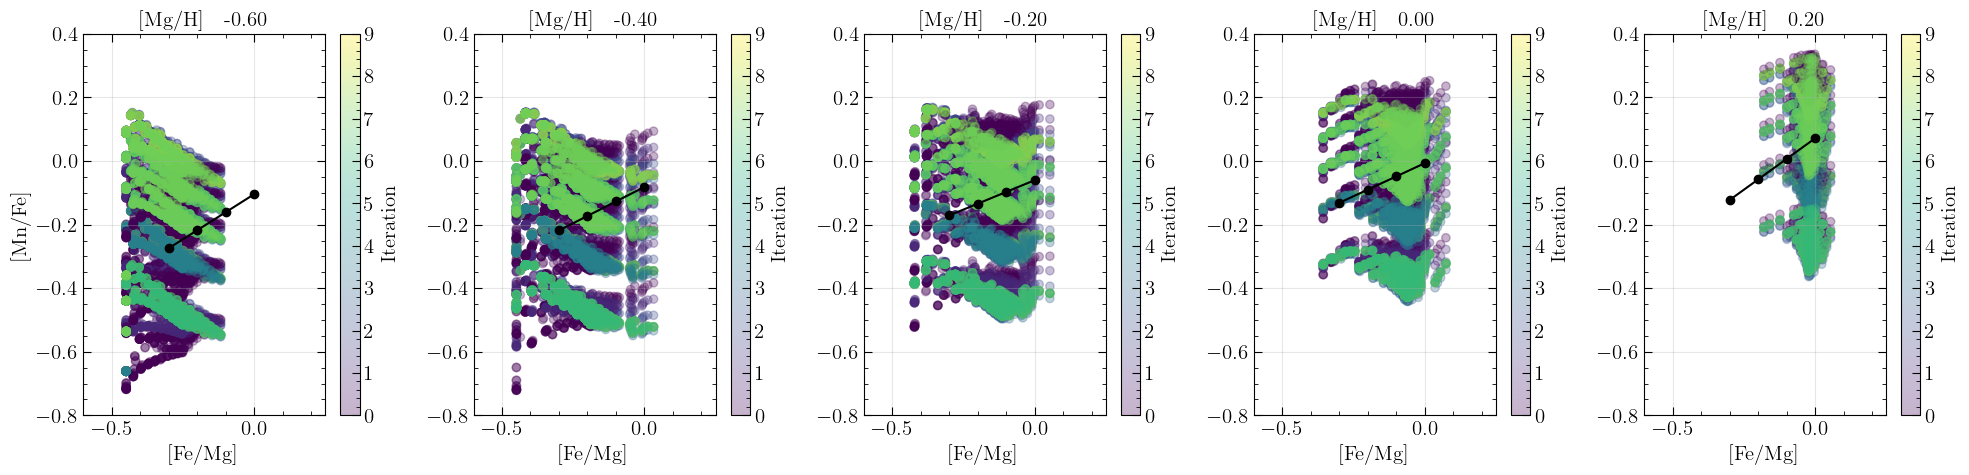

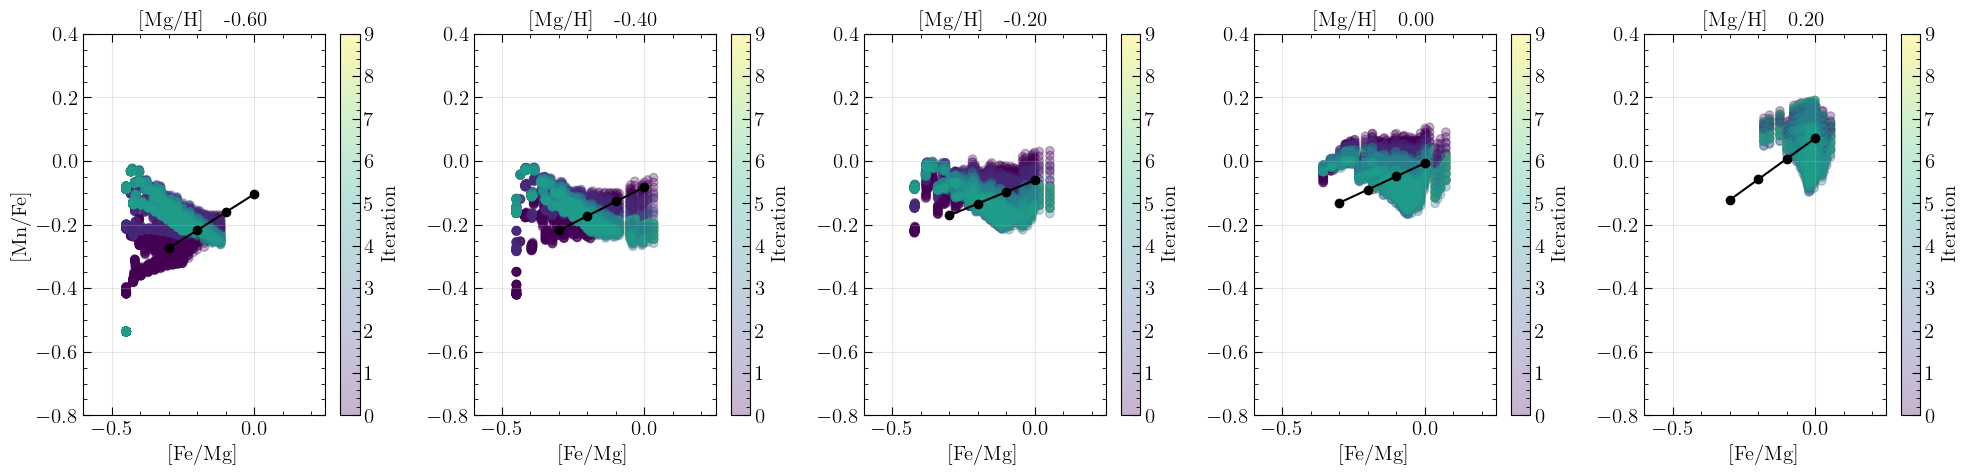

In [96]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_8_same_grid_len")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_8_same_grid_len")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_8_same_grid_len")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_8_same_grid_len")

# Models 9
--alpha_cc 0.80 --alpha_Ia 0.30 --g_cc 0.60 --g_ratio 1.50 --save_dir "unity_models_9"

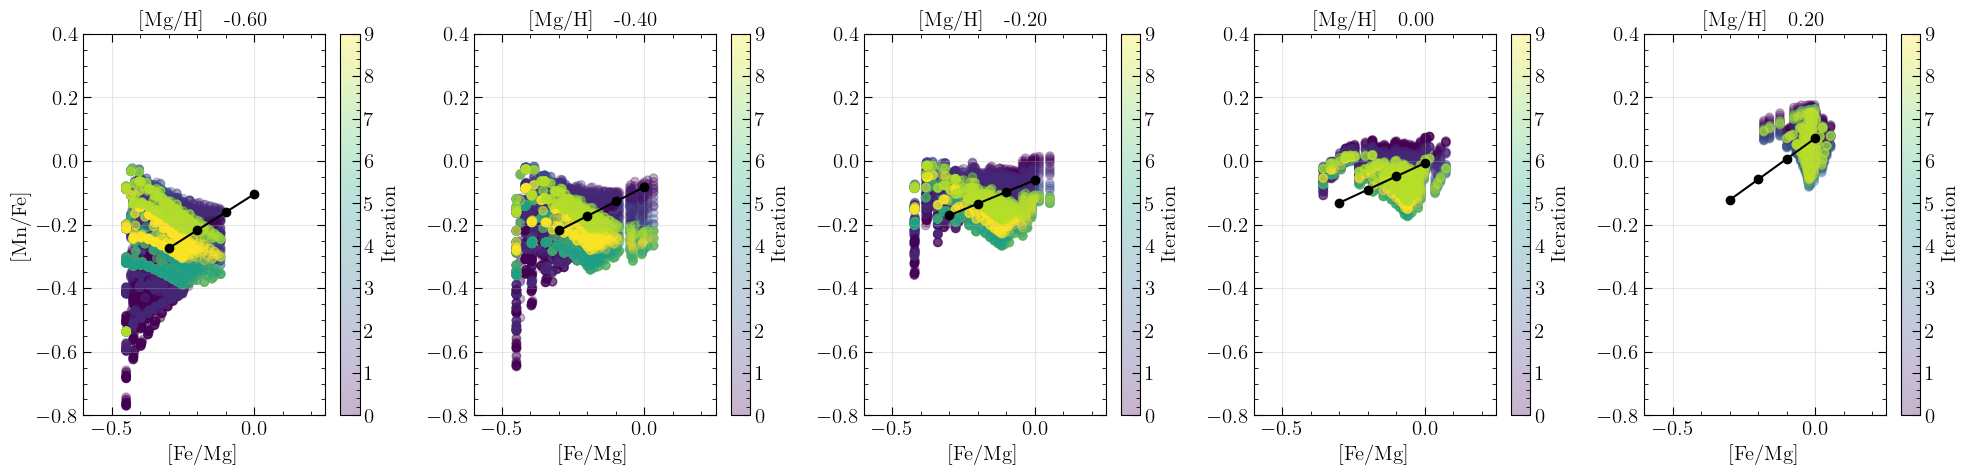

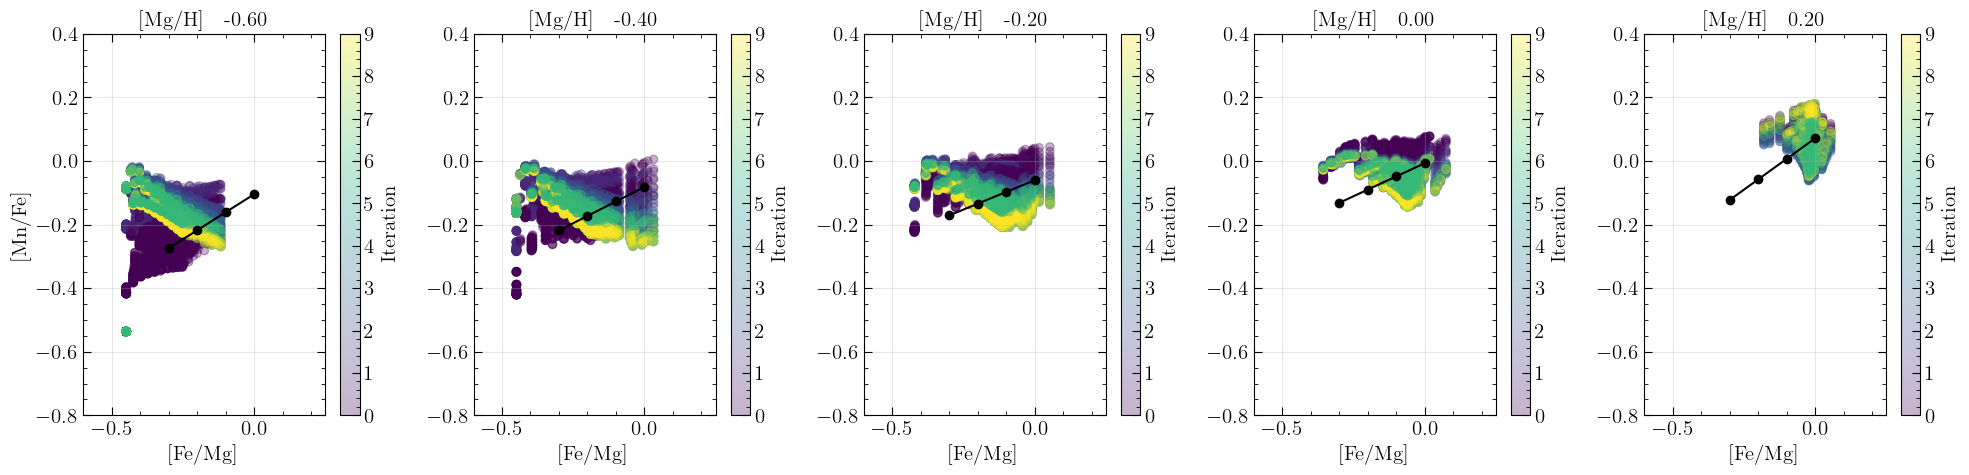

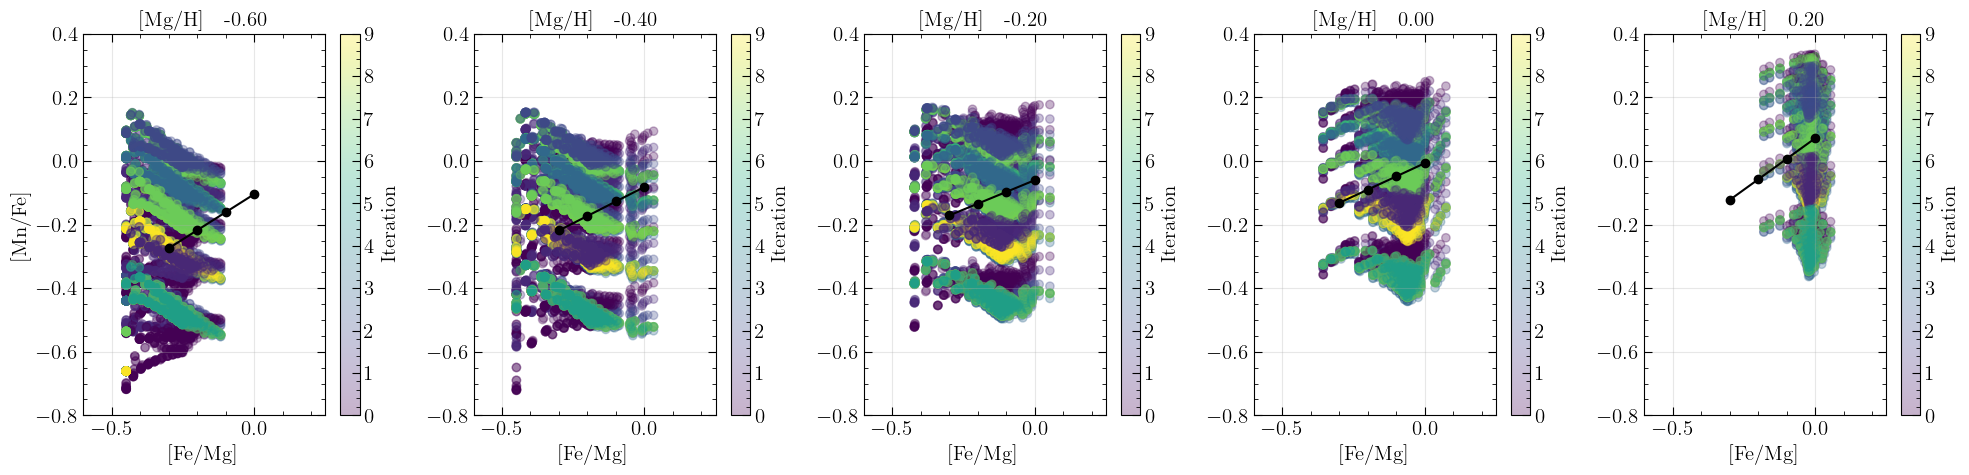

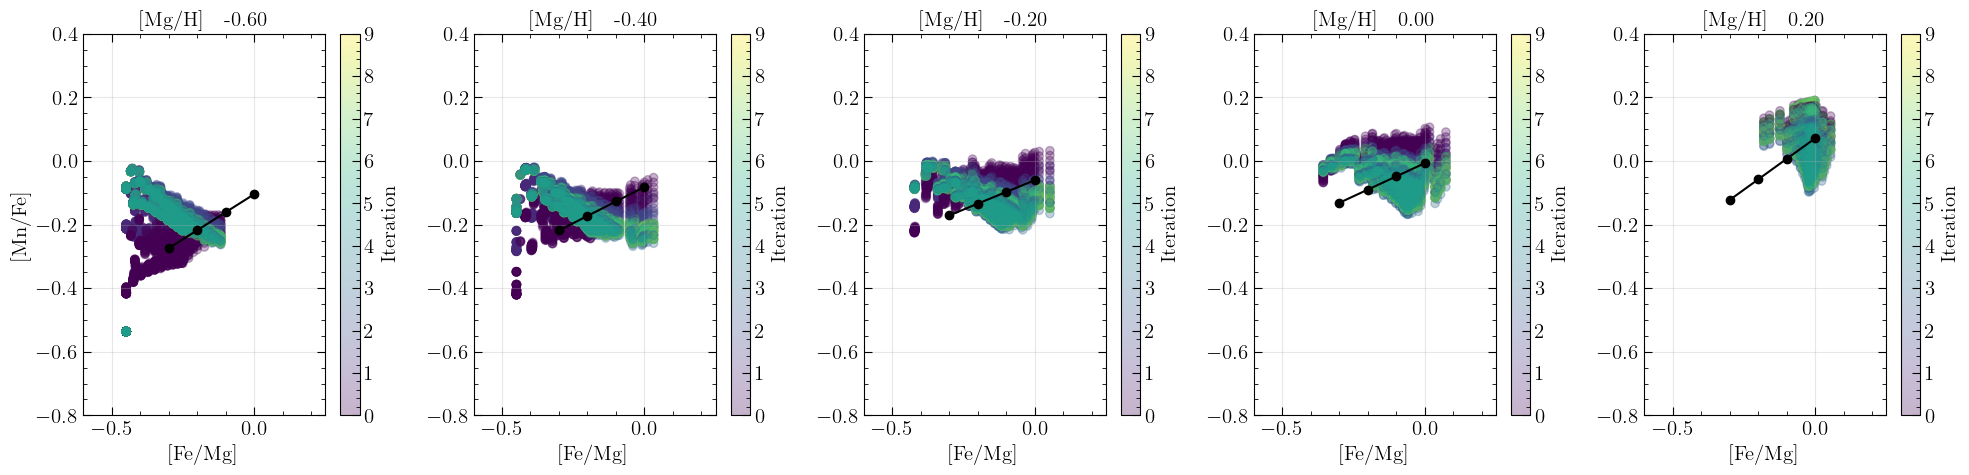

In [97]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_9_same_grid_len")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_9_same_grid_len")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_9_same_grid_len")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_9_same_grid_len")

In [98]:
opt_hist_model_9 = pd.read_csv('unity_models_9_same_grid_len/optimization_history.csv')
opt_hist_model_9

,iteration,optimized_param,best_val,alpha_cc,alpha_Ia,g_cc,g_ratio,grid_size
0,0,alpha_cc,0.4,0.4,0.3,0.4,1.9,0.1
1,0,alpha_Ia,0.4,0.4,0.4,0.4,1.9,0.1
2,0,g_cc,0.4,0.4,0.4,0.4,1.9,0.1
3,0,g_ratio,1.7,0.4,0.4,0.4,1.7,0.1
4,1,alpha_cc,0.2,0.2,0.4,0.4,1.7,0.1
5,1,alpha_Ia,0.6,0.2,0.6,0.4,1.7,0.1
6,1,g_cc,0.4,0.2,0.6,0.4,1.7,0.1
7,1,g_ratio,1.5,0.2,0.6,0.4,1.5,0.1
8,2,alpha_cc,0.1,0.1,0.6,0.4,1.5,0.1
9,2,alpha_Ia,0.8,0.1,0.8,0.4,1.5,0.1


# Read optimization history

In [99]:
opt_hist_model_8 = pd.read_csv('unity_models_8_same_grid_len/optimization_history.csv')

In [100]:
opt_hist_model_8

,iteration,optimized_param,best_val,alpha_cc,alpha_Ia,g_cc,g_ratio,grid_size
0,0,alpha_cc,0.4,0.4,0.3,0.4,1.9,0.1
1,0,alpha_Ia,0.4,0.4,0.4,0.4,1.9,0.1
2,0,g_cc,0.4,0.4,0.4,0.4,1.9,0.1
3,0,g_ratio,1.7,0.4,0.4,0.4,1.7,0.1
4,1,alpha_cc,0.2,0.2,0.4,0.4,1.7,0.1
5,1,alpha_Ia,0.6,0.2,0.6,0.4,1.7,0.1
6,1,g_cc,0.4,0.2,0.6,0.4,1.7,0.1
7,1,g_ratio,1.5,0.2,0.6,0.4,1.5,0.1
8,2,alpha_cc,0.1,0.1,0.6,0.4,1.5,0.1
9,2,alpha_Ia,0.8,0.1,0.8,0.4,1.5,0.1


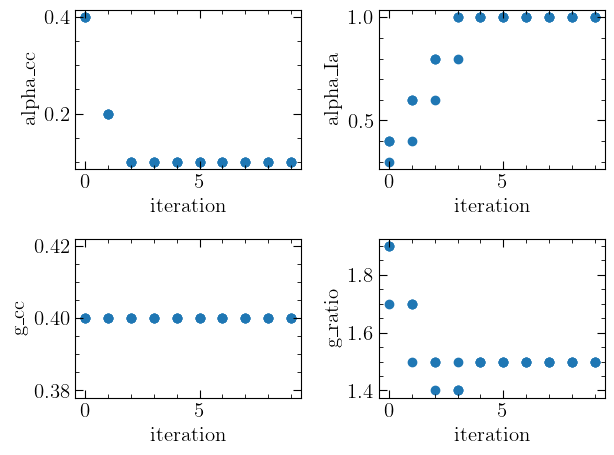

In [101]:
plt.subplot(2,2,1)
plt.scatter(opt_hist_model_8['iteration'], opt_hist_model_8['alpha_cc'])
plt.xlabel('iteration')
plt.ylabel("alpha_cc")

plt.subplot(2,2,2)
plt.scatter(opt_hist_model_8['iteration'], opt_hist_model_8['alpha_Ia'])
plt.xlabel('iteration')
plt.ylabel("alpha_Ia")

plt.subplot(2,2,3)
plt.scatter(opt_hist_model_8['iteration'], opt_hist_model_8['g_cc'])
plt.xlabel('iteration')
plt.ylabel("g_cc")

plt.subplot(2,2,4)
plt.scatter(opt_hist_model_8['iteration'], opt_hist_model_8['g_ratio'])
plt.xlabel('iteration')
plt.ylabel("g_ratio")

plt.tight_layout()